# ADRS vs DRS vs A2DR
## Benchmark: Nonnegative Least Squares (A2DR Section 7.1)

$$\min_{z \in \mathbb{R}^q} \|Fz - g\|^2 \quad \text{s.t.} \quad z \geq 0$$

**DRS splitting**: $g_1(x_1) = \|Fx_1 - g\|^2$, $g_2(x_2) = \iota_{\{z \geq 0\}}(x_2)$, with $x_1 = x_2$.

- $\mathrm{prox}_{t g_1}(v) = (F^\top F + \tfrac{1}{t}I)^{-1}(F^\top g + \tfrac{1}{t}v)$ — one linear solve (precomputed)
- $\mathrm{prox}_{g_2}(v) = \max(v, 0)$ — elementwise ReLU

$g_1$ is **strongly convex** (since $F^\top F \succ 0$), placing this in the regime where Goldstein et al. prove $O(1/k^2)$ for accelerated splitting.

**Note on residuals**: We plot $r_k = \|u_k - x_k\|$ (DRS fixed-point residual) for our methods,
and the combined primal+dual residual $\|r^k\| = \sqrt{\|r^k_\text{prim}\|^2 + \|r^k_\text{dual}\|^2}$ for A2DR.
Both measure proximity to the solution but are not identical — the comparison is qualitative.

In [3]:
%pip install -q a2dr

import numpy as np
import matplotlib.pyplot as plt
import io, sys
from a2dr import a2dr as solve_a2dr

np.random.seed(42)
plt.rcParams.update({'font.size':12,'lines.linewidth':2,'axes.grid':True,'grid.alpha':0.3})
COLORS = {'DRS':'#1f77b4','ADRS':'#ff7f0e','ADRS-M':'#2ca02c','ADRS-M-NM':'#d62728','A2DR':'#9467bd'}
STYLES = {'DRS':'-','ADRS':'--','ADRS-M':'-.','ADRS-M-NM':':','A2DR':'-'}


Note: you may need to restart the kernel to use updated packages.


In [4]:
# ── Problem setup (A2DR Section 7.1 dimensions) ──────────────────────
p_dim, q_dim = 300, 500

F3     = np.random.randn(p_dim, q_dim) * 0.1
z_true = np.maximum(np.random.randn(q_dim), 0)
g3     = F3 @ z_true + 0.01 * np.random.randn(p_dim)

FTF = F3.T @ F3
FTg = F3.T @ g3

# Precompute prox_g1 factorisation for alpha=1
ALPHA   = 1.0
Mi_nnls = np.linalg.inv(FTF + np.eye(q_dim) / ALPHA)

def prox_g1(v, a):
    """prox_{a * ||Fv-g||^2}: linear solve (precomputed for alpha=1)."""
    return Mi_nnls @ (FTg + v / a)

def prox_g2(v, a):
    """prox of nonneg indicator: ReLU."""
    return np.maximum(v, 0)

def drs_residual(u, x):
    return np.linalg.norm(u - x)

NITERS = 500
z0     = np.zeros(q_dim)

print(f'p={p_dim}, q={q_dim}')
print(f'g1 is strongly convex: lambda_min(F^TF) = {np.linalg.eigvalsh(FTF).min():.4f}')

p=300, q=500
g1 is strongly convex: lambda_min(F^TF) = -0.0000


In [5]:
# ── Algorithm implementations ─────────────────────────────────────────

def run_drs(z0, niters):
    z = z0.copy(); r = []
    for _ in range(niters):
        x = prox_g1(z, ALPHA); u = prox_g2(2*x - z, ALPHA)
        z = z + u - x; r.append(drs_residual(u, x))
    return np.array(r)

def run_adrs(z0, niters):
    z, zp, t, rp = z0.copy(), z0.copy(), 1.0, np.inf; r = []
    for _ in range(niters):
        tn = (1+np.sqrt(1+4*t**2))/2; beta = (t-1)/tn
        y  = z + beta*(z - zp)
        x  = prox_g1(y, ALPHA); u = prox_g2(2*x-y, ALPHA); rv = drs_residual(u, x)
        if rv > rp:
            tn=1.0; xs=prox_g1(z,ALPHA); us=prox_g2(2*xs-z,ALPHA)
            rv=drs_residual(us,xs); zp=z.copy(); z=z+us-xs
        else:
            zp=z.copy(); z=y+u-x
        t,rp=tn,rv; r.append(rv)
    return np.array(r)

def run_adrs_m(z0, niters):
    z, zp, t = z0.copy(), z0.copy(), 1.0; r = []; ni = 0
    for _ in range(niters):
        tn=(1+np.sqrt(1+4*t**2))/2; beta=(t-1)/tn; y=z+beta*(z-zp)
        xI=prox_g1(y,ALPHA); uI=prox_g2(2*xI-y,ALPHA); rI=drs_residual(uI,xI)
        xS=prox_g1(z,ALPHA); uS=prox_g2(2*xS-z,ALPHA); rS=drs_residual(uS,xS)
        if rI<=rS: zp,z,rv=z.copy(),y+uI-xI,rI; ni+=1
        else:      zp,z,rv=z.copy(),z+uS-xS,rS; tn=1.0
        t=tn; r.append(rv)
    print(f'  ADRS-M:    inertial {ni}/{niters} ({100*ni/niters:.0f}%)')
    return np.array(r)

def run_adrs_m_nm(z0, niters):
    z,zp=z0.copy(),z0.copy(); t=1.0
    xi=prox_g1(z,ALPHA); ui=prox_g2(2*xi-z,ALPHA); c=drs_residual(ui,xi)
    r=[]; ni=0
    for _ in range(niters):
        tn=(1+np.sqrt(1+4*t**2))/2; beta=(t-1)/tn; y=z+beta*(z-zp)
        xI=prox_g1(y,ALPHA); uI=prox_g2(2*xI-y,ALPHA); rI=drs_residual(uI,xI)
        if rI<=c: zp,z,rv=z.copy(),y+uI-xI,rI; ni+=1
        else:
            xS=prox_g1(z,ALPHA); uS=prox_g2(2*xS-z,ALPHA)
            zp,z,rv=z.copy(),z+uS-xS,drs_residual(uS,xS); tn=1.0
        c=rv; t=tn; r.append(rv)
    print(f'  ADRS-M-NM: inertial {ni}/{niters} ({100*ni/niters:.0f}%)')
    return np.array(r)

In [24]:
# ── Run our algorithms ────────────────────────────────────────────────
print('Running DRS variants...')
r_drs  = run_drs(z0, NITERS)
r_adrs = run_adrs(z0, NITERS)
r_m    = run_adrs_m(z0, NITERS)
r_nm   = run_adrs_m_nm(z0, NITERS)

# ── Run A2DR and collect per-iteration residuals ──────────────────────
print('\nRunning A2DR (Fu, Zhang & Boyd 2020)...')

def prox_g1_a2dr(v, t):
    """A2DR calls prox with its own stepsize t (after preconditioning)."""
    return np.linalg.solve(FTF + np.eye(q_dim)/(2*t), FTg + v/(2*t))

# Run A2DR: returns a dict
result = solve_a2dr(
    p_list=[prox_g1_a2dr, lambda v, t: np.maximum(v, 0)],
    A_list=[np.eye(q_dim), -np.eye(q_dim)],
    b=np.zeros(q_dim),
    anderson=True, M_safe=2, max_iter=NITERS,
    eps_abs=1e-14, eps_rel=1e-16, verbose=True
)

# A2DR returns a dict with primal and dual residuals for each iteration
print(f'\nA2DR result keys: {list(result.keys())}')
print(f'primal shape: {np.array(result["primal"]).shape}')
print(f'dual shape: {np.array(result["dual"]).shape}')
print(f'num_iters: {result["num_iters"]}')

# Extract residuals: A2DR returns arrays of residuals per iteration
r_primal = np.array(result['primal'])
r_dual = np.array(result['dual'])

# Compute combined residual (like A2DR's "total res" in verbose output)
a2dr_resids_full = np.sqrt(r_primal**2 + r_dual**2)

print(f'\nA2DR combined residuals for all {len(a2dr_resids_full)} iterations:')
print(f'  iter=   0: resid={a2dr_resids_full[0]:.2e}')
print(f'  iter= 100: resid={a2dr_resids_full[100]:.2e}')
print(f'  iter= 200: resid={a2dr_resids_full[200]:.2e}')
print(f'  iter= 300: resid={a2dr_resids_full[300]:.2e}')
print(f'  iter= 400: resid={a2dr_resids_full[400]:.2e}')
print(f'  iter= {len(a2dr_resids_full)-1}: resid={a2dr_resids_full[-1]:.2e}')


Running DRS variants...
  ADRS-M:    inertial 333/500 (67%)
  ADRS-M-NM: inertial 245/500 (49%)

Running A2DR (Fu, Zhang & Boyd 2020)...
----------------------------------------------------------------------
a2dr v0.2.3.post2 - Prox-Affine Distributed Convex Optimization Solver
                       (c) Anqi Fu, Junzi Zhang
                      Stanford University   2019
----------------------------------------------------------------------
### Preconditioning starts ... ###
### Preconditioning finished.  ###
max_iter = 500, t_init (after preconditioning) = 2.24
eps_abs = 1.00e-14, eps_rel = 1.00e-16, precond = True
ada_reg = True, anderson = True, m_accel = 10
lam_accel = 1.00e-08, aa_method = lstsq, D_safe = 1.00e+06
eps_safe = 1.00e-06, M_safe = 2
variables n = 1000, constraints m = 500
nnz(A) = 1000
Setup time: 4.65e-03
----------------------------------------------------
 iter | total res | primal res | dual res | time (s)
----------------------------------------------------
   

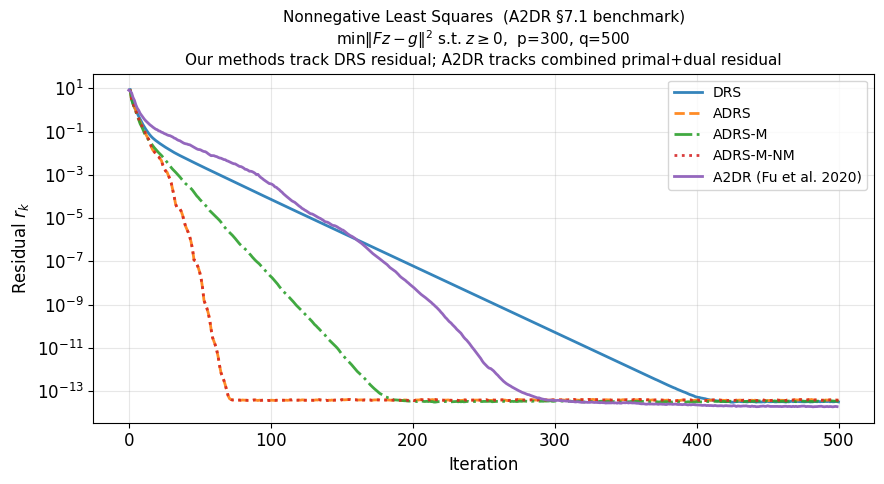

In [ ]:
# ── Convergence plot ──────────────────────────────────────────────────
iters = np.arange(1, NITERS+1)
a2dr_iters = np.arange(0, len(a2dr_resids_full))

fig, ax = plt.subplots(figsize=(9, 5))

# Our algorithms — dense curves
for name, r in [('DRS', r_drs), ('ADRS', r_adrs),
                ('ADRS-M', r_m), ('ADRS-M-NM', r_nm)]:
    ax.semilogy(iters, r, color=COLORS[name], linestyle=STYLES[name],
                label=name, alpha=0.9)

# A2DR — dense line (piecewise linear connecting all points)
ax.semilogy(a2dr_iters, a2dr_resids_full,
            color=COLORS['A2DR'], linestyle=STYLES['A2DR'],
            linewidth=2, label='A2DR',
            zorder=4)

ax.set_xlabel('Iteration')
ax.set_ylabel('Residual $r_k$')
ax.set_title(
    'Nonnegative Least Squares  (A2DR §7.1 benchmark)\n'
    f'$\\min\\|Fz-g\\|^2$ s.t. $z\\geq 0$,  p={p_dim}, q={q_dim}\n'
    'Our methods track DRS residual; A2DR tracks combined primal+dual residual',
    fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('nnls_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

